# 03 — Selección de variables

Decide qué variables del conjunto disponible entran en el modelo final, con qué
justificación, y qué implica esa decisión para las distintas familias de modelo
(lineal, árboles, stepwise). Todo el código vive en
[`src/analisis_seleccion.py`](../src/analisis_seleccion.py); este notebook lo ejecuta
sobre `data/interim/habitia_madrid_2018.csv` y recalcula las cifras en vivo.

**Alcance.** El análisis se hace sobre el mismo `train` (60.642 filas, split 80/20,
semilla 42) que usa `notebooks/04_datasets_modelado.ipynb` para escribir los datasets
finales: la selección de variables es una decisión que se toma con los mismos datos con
los que luego se entrena, nunca con el test.

**Criterio.** Con n = 60.642, la significación estadística está saturada (§1) y no sirve
para decidir. El criterio es **tamaño del efecto**: la contribución única de cada
variable al R² del modelo, medida como fracción de la varianza que el modelo aún no
explica. Se contrasta con un criterio de parada automático (stepwise, §8) y se completa
con razones de dominio que ninguna cifra de ajuste captura por sí sola (§7): resolución
espacial del dato, origen declarativo, categorías no cerradas, disponibilidad en
despliegue.

## 1. Modelo completo

Se construye la matriz con **todas** las variables candidatas, incluidas las que el
análisis acaba descartando — el argumento de un descarte es que su aporte medido es
despreciable, así que hay que medirlo con la variable dentro del modelo, no fuera.

In [1]:
import os, sys, warnings
from pathlib import Path

RAIZ = Path.cwd()
while not (RAIZ / "src").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
os.chdir(RAIZ); sys.path.insert(0, str(RAIZ))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

from src.limpieza import cargar_datos, limpiar_basico
from src.imputacion import fit_imputacion, aplicar_imputacion
from src.transformaciones import fit_transformaciones
from src import analisis_seleccion as asel

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

SEMILLA, TEST_SIZE = 42, 0.20

df, _ = train_test_split(limpiar_basico(cargar_datos()), test_size=TEST_SIZE, random_state=SEMILLA)
df = aplicar_imputacion(df, fit_imputacion(df))

y = np.log(df["PRICE"])
X_base = df.drop(columns=["PRICE"])
params = fit_transformaciones(X_base)

X = asel.transformar_variables_completa(X_base, params)

mapa = asel.mapa_variables(X.columns.tolist())
r2_completo = asel.r2_ols(X, y)
residual = 1 - r2_completo

print(f"Modelo completo: {len(mapa)} variables ({X.shape[1]} columnas tras dummificar), n = {len(y):,}")
print(f"R² = {r2_completo:.4f}   |   varianza aún sin explicar: {residual:.4f}")

Modelo completo: 37 variables (55 columnas tras dummificar), n = 60,375
R² = 0.9125   |   varianza aún sin explicar: 0.0875


Vemos que el modelo estándar ya explica el ~91% de la varianza de los datos, por lo que ese será nuestro *baseline*.

## 2. Por qué se descarta la significación estadística

La significación no se usa para decidir nada aquí
— se calcula solo con fines diagnósticos, para mostrar cuán saturado está el p-valor a
este tamaño de muestra. El criterio real es el tamaño del efecto (§3).

In [2]:
modelo_sm = sm.OLS(y.to_numpy(), sm.add_constant(X.astype("float64").to_numpy())).fit()
pvalores = pd.Series(modelo_sm.pvalues[1:], index=X.columns)

contribucion = asel.delta_r2_unico(X, y, mapa)
contribucion["p_min"] = contribucion["variable"].map(lambda v: pvalores[mapa[v]].min())

print(f"Variables con p < 0,05: {(contribucion['p_min'] < 0.05).sum()} de {len(contribucion)}")
print(f"Variables que recuperan >= {asel.UMBRAL_RESIDUAL:.0%} de la varianza residual: "
      f"{(contribucion['cuota_residual'] >= asel.UMBRAL_RESIDUAL).sum()}")

Variables con p < 0,05: 30 de 37
Variables que recuperan >= 1% de la varianza residual: 9


In [3]:
print("\nEjemplo — variables altamente significativas, aporte despreciable:")
ejemplo = contribucion[contribucion["p_min"] < 0.05].nsmallest(5, "delta_r2_unico")
print(ejemplo[["variable", "p_min", "delta_r2_unico", "cuota_residual"]].to_string(index=False))


Ejemplo — variables altamente significativas, aporte despreciable:
           variable    p_min  delta_r2_unico  cuota_residual
HASNORTHORIENTATION 0.034786        0.000006        0.000074
  log_dist_parque_m 0.026245        0.000007        0.000082
     alturaedif_cat 0.037617        0.000010        0.000113
       ISINTOPFLOOR 0.007477        0.000010        0.000119
 HASWESTORIENTATION 0.002303        0.000013        0.000154


In [4]:
contribucion

,variable,k_columnas,r2_sin,delta_r2_unico,cuota_residual,p_min
0,superficie,2,0.849975,6.252008e-02,0.714474,0.000000e+00
1,indice_vulnerabilidad,1,0.905382,7.112976e-03,0.081286,0.000000e+00
2,alq_mediana_eur_m2_barrio,1,0.905870,6.624610e-03,0.075705,0.000000e+00
3,HASLIFT,1,0.908738,3.757331e-03,0.042938,0.000000e+00
4,planta_cat,3,0.909618,2.876553e-03,0.032873,0.000000e+00
5,BATHNUMBER,1,0.909848,2.647249e-03,0.030253,0.000000e+00
6,log_dist_centro,1,0.910088,2.406826e-03,0.027505,0.000000e+00
7,BUILTTYPEID_2,1,0.910751,1.744060e-03,0.019931,7.507919e-261
8,log_dist_castellana,1,0.911465,1.030219e-03,0.011773,1.484460e-155
9,HASAIRCONDITIONING,1,0.911675,8.196082e-04,0.009366,2.605885e-124


## 3. Criterio: contribución única como cuota de varianza residual

Para cada variable, `delta_r2_unico` mide **ΔR² = R²(modelo completo) − R²(modelo sin
esa variable)** — la correlación semiparcial al cuadrado de esa variable con log(PRICE),
dado todo lo demás. Se lee como `cuota_residual = ΔR² / (1 − R²)`: la fracción de la
varianza **que aún queda por explicar** que esa variable recupera. Es la escala correcta
para fijar un umbral — con R² ya en 0,91, exigir un porcentaje de la varianza *total* es
exigir un porcentaje mucho mayor de lo que queda disponible.

**Umbral: 1% de la varianza residual** (`asel.UMBRAL_RESIDUAL`), en tres niveles:

| cuota residual | veredicto |
|---|---|
| ≥ 1% | el ajuste basta para incluir |
| 0,25% – 1% | el ajuste no decide por sí solo — deciden los criterios de §7 |
| < 0,25% | el ajuste no sostiene la inclusión |

Dos advertencias sobre esta métrica, que se comprueban más abajo en vez de darlas por
supuestas: **infravalora a las variables redundantes** (si dos variables comparten
señal, quitar cualquiera de ellas apenas baja el R², y ambas salen con ΔR² pequeño pese a
aportar mucho juntas — se cuantifica en §9.1), y **dentro de muestra nunca puede ser
negativo** (el R² no baja al añadir columnas, así que nunca puede argumentar *en contra*
de una variable — se corrige con validación cruzada en §3.2).

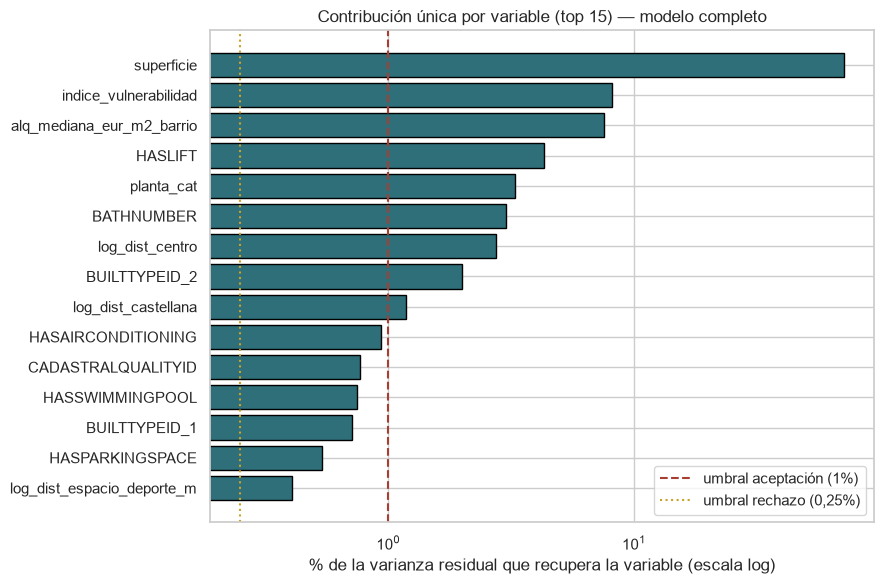

In [5]:
top = contribucion.sort_values("cuota_residual", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["variable"], top["cuota_residual"] * 100, color="#2f6f7a", edgecolor="black")
ax.axvline(asel.UMBRAL_RESIDUAL * 100, color="#a83e32", linestyle="--", label="umbral aceptación (1%)")
ax.axvline(asel.UMBRAL_RESIDUAL * 25, color="#c9a227", linestyle=":", label="umbral rechazo (0,25%)")
ax.set_xscale("log")
ax.set_xlabel("% de la varianza residual que recupera la variable (escala log)")
ax.set_title("Contribución única por variable (top 15) — modelo completo")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

## 4. Descomposición por bloques semánticos

La pregunta útil no es "¿cuánto aporta `log_area`?" sino "¿cuánto aporta **saber el
tamaño**?". Se agrupan las variables por lo que miden y se calcula, para cada bloque, su
R² en solitario y su ΔR² único. El contraste entre ambos es lo interesante: un bloque
con R² alto en solitario y ΔR² único ≈ 0 mide algo real, pero ya contenido en otros
bloques.

In [6]:
bloques = asel.bloques_semanticos(X.columns.tolist())
tabla_bloques = asel.descomposicion_bloques(X, y, bloques)
tabla_bloques["cuota_residual"] = tabla_bloques["delta_r2_unico"] / residual
print(tabla_bloques.round(4).to_string(index=False))

       bloque  k  r2_bloque_solo  delta_r2_unico  cuota_residual
       TAMAÑO 10          0.6816          0.1928          2.2037
 LOCALIZACIÓN 11          0.5267          0.1033          1.1810
     EDIFICIO 17          0.4862          0.0091          0.1044
INSTALACIONES 11          0.2613          0.0041          0.0470
          POI  4          0.0766          0.0004          0.0048
  ORIENTACIÓN  4          0.0285          0.0000          0.0003


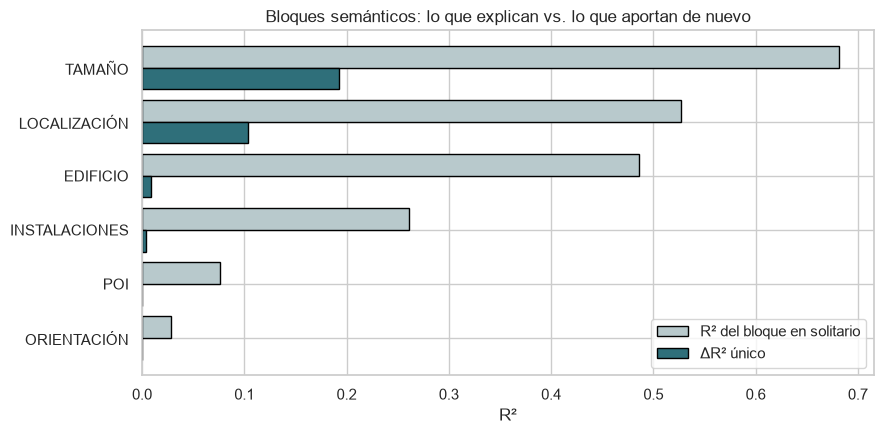

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
t = tabla_bloques.iloc[::-1]
posicion = np.arange(len(t))
ax.barh(posicion + 0.2, t["r2_bloque_solo"], height=0.4,
        color="#b8c9cc", edgecolor="black", label="R² del bloque en solitario")
ax.barh(posicion - 0.2, t["delta_r2_unico"], height=0.4,
        color="#2f6f7a", edgecolor="black", label="ΔR² único")
ax.set_yticks(posicion); ax.set_yticklabels(t["bloque"])
ax.set_xlabel("R²")
ax.set_title("Bloques semánticos: lo que explican vs. lo que aportan de nuevo")
ax.legend()
plt.tight_layout(); plt.show()

**Tamaño y localización son el modelo**: concentran prácticamente todo el ΔR² único.
**Edificio** explica bastante en solitario pero aporta poco de nuevo — calidad
catastral, época y altura son en su mayoría *proxies* de barrio y tamaño. **Instalaciones**
son marcadores de vivienda cara ya capturados por superficie y barrio. **Orientación y
POI** aportan casi cero como bloque (razones de fondo en §7).

## 5. Cuántas variables hacen falta

En el apartado se ve qué parte residual aporta cada variable a la explicabilidad de la varianza, en orden descendente.

Selección forward **por variable**: una categórica entra con todas sus dummies de
golpe, y las dos bases de la *spline* de superficie (`log_area`, `log_area_50`) entran
juntas — son una variable partida en dos columnas, no dos variables.

In [8]:
forward = asel.seleccion_forward(X, y, mapa, max_pasos=12)
print(forward.round(3).to_string(index=False))

 paso                  variable    r2  pct_r2_completo
    1                superficie 0.628           68.770
    2 alq_mediana_eur_m2_barrio 0.863           94.630
    3                   HASLIFT 0.880           96.408
    4     indice_vulnerabilidad 0.885           96.975
    5             BUILTTYPEID_2 0.889           97.473
    6           log_dist_centro 0.894           97.988
    7           HASSWIMMINGPOOL 0.899           98.494
    8                planta_cat 0.902           98.869
    9                BATHNUMBER 0.906           99.265
   10        HASAIRCONDITIONING 0.907           99.393
   11       log_dist_castellana 0.908           99.498
   12        CADASTRALQUALITYID 0.909           99.595


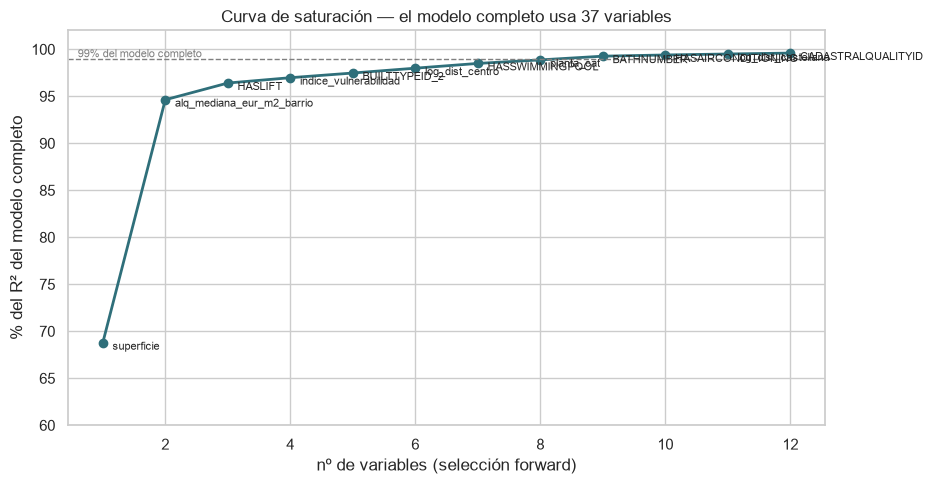

 2 variables -> 94.6% del R² del modelo completo
 9 variables -> 99.3% del R² del modelo completo
12 variables -> 99.6% del R² del modelo completo


In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(forward["paso"], forward["pct_r2_completo"], marker="o", color="#2f6f7a", linewidth=2)
for _, fila in forward.iterrows():
    ax.annotate(fila["variable"], (fila["paso"], fila["pct_r2_completo"]),
                textcoords="offset points", xytext=(7, -5), fontsize=8)
ax.axhline(99, linestyle="--", color="grey", linewidth=1)
ax.text(0.6, 99.15, "99% del modelo completo", fontsize=8, color="grey")
ax.set_xlabel("nº de variables (selección forward)")
ax.set_ylabel("% del R² del modelo completo")
ax.set_title(f"Curva de saturación — el modelo completo usa {len(mapa)} variables")
ax.set_ylim(60, 102)
plt.tight_layout(); plt.show()

for k in (2, 9, 12):
    print(f"{k:>2} variables -> {forward.loc[k - 1, 'pct_r2_completo']:.1f}% del R² del modelo completo")

**Superficie y nivel de alquiler del barrio dan el 94%. Nueve variables dan el 99%.**
Un modelo de 9 a 18 variables es prácticamente indistinguible en ajuste de uno con las
37, y mucho más defendible, interpretable y estable.

La curva es dentro de muestra —no puede bajar al añadir variables—, así que la
saturación en sí es en parte mecánica; lo que no lo es, es *dónde* satura y con qué
pocos pasos.

## 6 Interacciones

Los modelos de árbol aprenden interacciones solos, a través de sus cortes sucesivos:
esta comprobación aplica solo a la vía lineal, que es aditiva y no puede representar que
el efecto de una variable cambie según el valor de otra. Siete candidatas, motivadas por
los bloques dominantes (tamaño × localización) y por las dos variables con forma no
lineal ya documentada (calidad catastral, planta).

In [10]:
df_i = X.copy()
candidatas = {}

for nombre, col_loc in [("log_area x alq_barrio", "alq_mediana_eur_m2_barrio"),
                        ("log_area x dist_centro", "log_dist_centro"),
                        ("log_area x vulnerabilidad", "indice_vulnerabilidad")]:
    df_i[nombre] = df_i["log_area"] * df_i[col_loc]
    candidatas[nombre] = [nombre]

cols_planta = [c for c in X.columns if c.startswith("planta_cat_")]
df_i, cols_planta_ascensor = asel.terminos_interaccion(df_i, "HASLIFT", cols_planta, "planta_x_ascensor")
candidatas["planta x ascensor (bloque)"] = cols_planta_ascensor

df_i["log_area x tipologia"] = df_i["log_area"] * df_i["BUILTTYPEID_2"]
candidatas["log_area x tipologia"] = ["log_area x tipologia"]

df_i["banos x habitaciones"] = df_i["BATHNUMBER"] * df_i["habitaciones_cat_3"]
candidatas["banos x habitaciones"] = ["banos x habitaciones"]

cols_epoca = [c for c in X.columns if c.startswith("epoca_construccion_")]
df_i, cols_cal_epoca = asel.terminos_interaccion(df_i, "CADASTRALQUALITYID", cols_epoca, "calidad_x")
candidatas["calidad x epoca (bloque)"] = cols_cal_epoca

resultados = []
for nombre, cols in candidatas.items():
    delta = asel.r2_ols(df_i[list(X.columns) + cols], y) - r2_completo
    resultados.append({"interaccion": nombre, "k": len(cols), "delta_r2": delta,
                       "cuota_residual": asel.cuota_residual(delta, r2_completo)})

tabla_int = pd.DataFrame(resultados).sort_values("cuota_residual", ascending=False)
tabla_int["veredicto"] = tabla_int["delta_r2"].map(lambda d: asel.veredicto(d, r2_completo))
print(tabla_int.round(5).to_string(index=False))

               interaccion  k  delta_r2  cuota_residual           veredicto
     log_area x alq_barrio  1   0.00070         0.00797 el ajuste no decide
    log_area x dist_centro  1   0.00049         0.00565 el ajuste no decide
planta x ascensor (bloque)  3   0.00043         0.00491 el ajuste no decide
 log_area x vulnerabilidad  1   0.00032         0.00363 el ajuste no decide
      log_area x tipologia  1   0.00021         0.00243  descartar (ajuste)
  calidad x epoca (bloque)  7   0.00007         0.00081  descartar (ajuste)
      banos x habitaciones  1   0.00006         0.00071  descartar (ajuste)


**Ninguna interacción supera el umbral: se descartan las 7.** La mejor, superficie por
alquiler de barrio, se queda cerca del 1% sin llegar — y aun si lo superara, un término
de interacción destruye la lectura directa de la elasticidad de superficie (el
coeficiente deja de leerse como "el efecto del tamaño" y pasa a depender del barrio), que
es precisamente lo que la vía lineal está para ofrecer. Para ganar ajuste está la vía de
árboles, que aprende estas interacciones sin coste adicional de interpretabilidad
sacrificada.

## 7. Criterios de dominio que el ajuste no captura

Cuatro problemas de significado que ninguna métrica de ajuste detecta por sí sola, y que
pesan en la decisión final tanto como la cuota residual.

### 7.1 Resolución espacial: el ruido de anonimización

Las coordenadas llevan ruido de anonimización (σ ≈ 38 m por eje, **p95 ≈ 94 m** de
desplazamiento radial). Cualquier distancia construida a partir de ellas hereda ese
error. La pregunta relevante no es "¿esta distancia correlaciona con el precio?" sino
**"¿tiene el dato resolución para medirla con fiabilidad?"**.

In [11]:
P95_RUIDO = 94.0  # metros

cols_dist = ["dist_centro_educativo_m", "dist_espacio_deporte_m", "dist_centro_medico_m",
             "DISTANCE_TO_METRO", "dist_parque_m", "DISTANCE_TO_CASTELLANA", "DISTANCE_TO_CITY_CENTER"]

filas = []
for c in cols_dist:
    s = df[c].astype("float64")
    s_m = s * 1000 if c.startswith("DISTANCE_TO") else s
    filas.append({"variable": c, "mediana_m": s_m.median(), "ruido/mediana": P95_RUIDO / s_m.median()})

tabla_ruido = pd.DataFrame(filas).sort_values("mediana_m")
print(tabla_ruido.round(3).to_string(index=False))

               variable  mediana_m  ruido/mediana
dist_centro_educativo_m    146.800          0.640
 dist_espacio_deporte_m    287.200          0.327
   dist_centro_medico_m    324.300          0.290
      DISTANCE_TO_METRO    329.837          0.285
          dist_parque_m    467.700          0.201
 DISTANCE_TO_CASTELLANA   1949.793          0.048
DISTANCE_TO_CITY_CENTER   4093.351          0.023


Las dos únicas distancias que sobreviven en §9 son exactamente las dos cuya escala (2–4
km) deja el ruido muy por debajo: `DISTANCE_TO_CASTELLANA` y `DISTANCE_TO_CITY_CENTER`.
Las distancias a POI se miden en cientos de metros — un orden de magnitud demasiado
cerca del ruido. El descarte no es "estos servicios no afectan al precio", es "este
dataset no tiene resolución espacial para medirlo"; se recuperaría agregando a nivel de
barrio (p. ej. nº de colegios por km²) en vez de como distancia puntual.

**Limitación del dataset**: Las distancias a POI son suficientemente pequeñas en magnitud como para que el ruido de anonimización las neutralice.

### 7.2 Origen declarativo y riesgo de *drift*

Un `0` en `HASWARDROBE` o `HASBOXROOM` no significa "no tiene": significa "el
anunciante no lo marcó". Si el modelo se aplica a datos de la API de idealista de 2026,
estas variables son las más expuestas a *drift*, porque dependen de cómo rellenen el
formulario los anunciantes, no de cómo sea el parque de viviendas. `HASLIFT` es la
excepción: entra en el paso 3 de la forward y es un atributo estructural, difícil de
declarar mal.

### 7.3 Orientación: categoría no cerrada

In [12]:
orient = [c for c in df.columns if "ORIENTATION" in c]
n_declaradas = df[orient].sum(axis=1)
print(f"Inmuebles con alguna orientación declarada: {(n_declaradas > 0).mean():.1%}")
print(f"Inmuebles con más de una:                   {(n_declaradas > 1).mean():.1%}")

Inmuebles con alguna orientación declarada: 46.8%
Inmuebles con más de una:                   17.9%


Solo el 46,9% declara alguna orientación y un 17,9% declara más de una: no son *dummies*
mutuamente excluyentes, y `0` significa "sin dato", no "no orientado al norte".

### 7.4 `CADASTRALQUALITYID`: invertida y no monótona

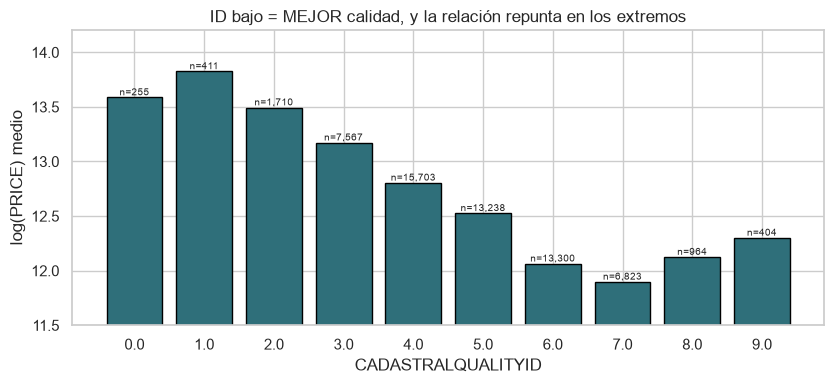

In [13]:
orden = sorted(df["CADASTRALQUALITYID"].dropna().unique())
resumen = df.assign(log_PRICE=y).groupby("CADASTRALQUALITYID", observed=True)["log_PRICE"].agg(["mean", "count"]).reindex(orden)

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.bar(resumen.index.astype(str), resumen["mean"], color="#2f6f7a", edgecolor="black")
for i, (m, n) in enumerate(zip(resumen["mean"], resumen["count"])):
    ax.text(i, m, f"n={int(n):,}", ha="center", va="bottom", fontsize=7.5)
ax.set_ylim(11.5, 14.2)
ax.set_ylabel("log(PRICE) medio"); ax.set_xlabel("CADASTRALQUALITYID")
ax.set_title("ID bajo = MEJOR calidad, y la relación repunta en los extremos")
plt.tight_layout(); plt.show()

Un ID bajo es mejor calidad, no peor — el coeficiente en un modelo lineal sale negativo,
y hay que leerlo así en la memoria. La relación repunta en 8 y 9, así que tampoco es
estrictamente ordinal en los extremos: tratarla como categórica, o verificar el signo
antes de interpretar.

### 7.5 Disponibilidad en despliegue: los campos `CAD*`

`CADCONSTRUCTIONYEAR`, `CADMAXBUILDINGFLOOR`, `CADDWELLINGCOUNT`, `CADASTRALQUALITYID` y
`BUILTTYPEID_*` vienen precalculados mediante un cruce con la dirección real que el
dataset anonimizado no contiene — no estarían disponibles en producción sin reconstruir
ese enriquecimiento. Como el aporte único del bloque EDIFICIO es pequeño (§4), la
recomendación es cómoda: construir la variante *desplegable* sin estos campos y
comparar contra la variante enriquecida — la diferencia entre ambas es en sí misma un
resultado del TFM. El notebook 04 materializa las dos.

In [14]:
mask = ["dist_espacio_deporte_m", "dist_parque_m", "dist_centro_medico_m", "dist_centro_educativo_m"]
tabla_delta_poi = contribucion[contribucion["variable"].str.contains("dist_", case=False)]
print("ΔR² único de las 4 distancias a POI, para contraste con §9:")
print(tabla_delta_poi[["variable", "delta_r2_unico", "cuota_residual"]].round(5).to_string(index=False))

ΔR² único de las 4 distancias a POI, para contraste con §9:
                   variable  delta_r2_unico  cuota_residual
            log_dist_centro         0.00241         0.02750
        log_dist_castellana         0.00103         0.01177
 log_dist_espacio_deporte_m         0.00036         0.00406
             log_dist_metro         0.00026         0.00297
   log_dist_centro_medico_m         0.00003         0.00035
log_dist_centro_educativo_m         0.00002         0.00025
          log_dist_parque_m         0.00001         0.00008


### 7.6 `delitos_q`: ¿la U es un efecto real o es centralidad disfrazada?

`delitos_q` cae en la banda gris del criterio de §3 (el ajuste no decide por sí solo) y su relación marginal con log(PRICE) tiene forma de U: el distrito Centro concentra a la vez más delitos registrados y precios más altos. Antes de leer esa U como un efecto del delito, hay que comprobar si sobrevive a controlar por centralidad, que el modelo ya mide con `alq_mediana_eur_m2_barrio`, `indice_vulnerabilidad`, `log_dist_centro` y `log_dist_castellana`: se regresa log(PRICE) contra las otras 36 variables y se compara la U marginal con la misma U calculada sobre lo que ese modelo no explica.

In [15]:
from sklearn.linear_model import LinearRegression
from src import transformaciones as t

quintil = t._transformar_delitos(X_base.copy(), params)["delitos_q"].loc[X.index]
marginal = y.groupby(quintil, observed=True).mean().rename("media_marginal_log_precio")

cols_delitos = [c for c in X.columns if c.startswith("delitos_q_")]
cols_resto = [c for c in X.columns if c not in cols_delitos]
modelo_sin_delitos = LinearRegression().fit(X[cols_resto].astype("float64"), y)
residuo = y - modelo_sin_delitos.predict(X[cols_resto].astype("float64"))  
parcial = residuo.groupby(quintil, observed=True).mean().rename("residuo_medio_controlando_resto")

tabla_delitos_q = pd.concat([marginal, parcial], axis=1)
tabla_delitos_q["n"] = quintil.value_counts().reindex(tabla_delitos_q.index)
print(tabla_delitos_q.round(4).to_string())

corr_centro = X_base["delitos_per_10k_barrio"].corr(X_base["DISTANCE_TO_CITY_CENTER"])
corr_alq = X_base["delitos_per_10k_barrio"].corr(X_base["alq_mediana_eur_m2_barrio"])
print(f"\ncorr(delitos_per_10k_barrio, DISTANCE_TO_CITY_CENTER) = {corr_centro:.3f}")
print(f"corr(delitos_per_10k_barrio, alq_mediana_eur_m2_barrio) = {corr_alq:.3f}")

           media_marginal_log_precio  residuo_medio_controlando_resto      n
delitos_q                                                                   
Q1                           12.6843                           0.0034  12435
Q2                           12.6308                          -0.0169  11884
Q3                           12.3537                           0.0136  11997
Q4                           12.3596                          -0.0127  12333
Q5                           12.6723                           0.0130  11726

corr(delitos_per_10k_barrio, DISTANCE_TO_CITY_CENTER) = -0.425
corr(delitos_per_10k_barrio, alq_mediana_eur_m2_barrio) = 0.216


**La U no sobrevive: era centralidad, no delito.** Sin controles, los quintiles extremos (menos y más delitos) son los más caros — una U clara. Controlando por las otras 36 variables, esa diferencia se reduce a oscilaciones de ±1-1,5% sin patrón: ya no es una U, es ruido.

**Conclusión: se descarta.** Se conserva como hallazgo narrativo para la memoria (el delito *registrado* en Madrid marca zonas turísticas/de ocio caras más que inseguridad residencial), no como variable del modelo.

## 8. Comprobación independiente: selección stepwise (AIC / BIC)

Todo lo anterior depende de un umbral fijado a mano (1% de varianza residual). Stepwise
con parada por AIC o BIC decide **cuándo parar por sí mismo**: es la comprobación
independiente de cuántas variables sostiene un criterio automático, y la única forma de
saber si POI u orientación llegarían a entrar bajo ese criterio (la curva forward de §5
nunca se extendió más allá del paso 12).

In [16]:
sw_bic = asel.seleccion_stepwise(X, y, mapa, criterio="bic")
sw_aic = asel.seleccion_stepwise(X, y, mapa, criterio="aic")

print(f"BIC selecciona {len(sw_bic.attrs['seleccionadas'])} de {len(mapa)} variables")
print(f"AIC selecciona {len(sw_aic.attrs['seleccionadas'])} de {len(mapa)} variables")
print(f"\nNo seleccionadas por BIC: {sw_bic.attrs['no_seleccionadas']}")

BIC selecciona 27 de 37 variables
AIC selecciona 35 de 37 variables

No seleccionadas por BIC: ['HASTERRACE', 'HASNORTHORIENTATION', 'HASSOUTHORIENTATION', 'HASEASTORIENTATION', 'HASGARDEN', 'ISSTUDIO', 'ISINTOPFLOOR', 'log_dist_parque_m', 'sin_match_catastral', 'alturaedif_cat']


**AIC retiene 33 de 37 y no se usa para decidir nada**: con n = 60.642 su penalización
fija (2 por parámetro) es trivial frente a la mejora de verosimilitud de cualquier
variable con efecto real, así que reproduce la misma saturación que ya se vio con
p < 0,05 en §2.

**BIC retiene 26 de 37**, penalización k·ln(n) ≈ 11·k por variable, y confirma el descarte de las 4 orientaciones sin conocer el argumento
de §7.3, pero **mantiene 3 de las 4 distancias a POI** (todas menos `log_dist_centro_educativo_m`, la de mayor ruido relativo, §7.1) y otras 6 variables que este análisis descarta (`HASDOORMAN`, `HASBOXROOM`, `HASWARDROBE`, `ISDUPLEX`, `delitos_q`,
`log_viviendas_edif`).

Esto no contradice §7.1 . Que BIC detecte
*algo* es compatible con esa lectura — lo que BIC no puede decir es si ese algo es señal
real o el residuo de la degradación por ruido, y esa distinción solo la da un argumento
de dominio, no una cifra de ajuste. Además, BIC tampoco es inmune al problema de fondo
de este notebook: la mejora de verosimilitud de un efecto real crece con *n* mientras su
penalización solo crece con *ln(n)* —  "distinguible de cero" y "vale la pena incluir" son preguntas distintas.

## 9. Conjunto final de variables

Una decisión por variable — incluir o descartar —, sin niveles intermedios. Cada fila
lleva su cuota residual y la razón que decide cuándo esa cifra no basta por sí sola: la
cuota residual no separa limpiamente incluir de descartar con un único corte —
`log_dist_castellana`, `HASSWIMMINGPOOL`, `BUILTTYPEID_1`, `CADASTRALQUALITYID`,
`HASPARKINGSPACE`, `log_dist_metro`, `epoca_construccion` y `habitaciones_cat` se
incluyen desde la banda donde el ajuste no decide por sí solo (§3), por razones
estructurales de §6-§7.

In [ ]:
DECISION = {
    # --- el ajuste basta (cuota residual >= 1%) ---
    "superficie": ("incluir", "Recupera sola ~74% de la varianza residual (paso 1 de la forward); el nudo en 50 m² capta el suelo de precio en pisos pequeños."),
    "indice_vulnerabilidad": ("incluir", "Mayor ΔR² único del modelo pese a la colinealidad con alq_mediana_eur_m2_barrio (§9.1): aporta señal propia."),
    "alq_mediana_eur_m2_barrio": ("incluir", "Paso 2 de la forward: junto a superficie alcanza el 94% del R² del modelo completo."),
    "HASLIFT": ("incluir", "Paso 3 de la forward; estructural, no declarativo (§7.2)."),
    "planta_cat": ("incluir", "Quinta mayor cuota residual del modelo, con la matriz depurada de dependencias lineales exactas (§1)."),
    "BATHNUMBER": ("incluir", "Relación casi lineal en log(PRICE); decidida por ajuste."),
    "log_dist_centro": ("incluir", "Gradiente centro-periferia, con ruido de anonimización muy por debajo de su escala (§7.1)."),
    "BUILTTYPEID_2": ("incluir", "Tipología constructiva, categoría cerrada; se evalúa junto a BUILTTYPEID_1."),
    "HASAIRCONDITIONING": ("incluir", "En el umbral del 1% de varianza residual; entra por ajuste."),
    # --- el ajuste no decide por sí solo; razón estructural ---
    "log_dist_castellana": ("incluir", "Colineal con log_dist_centro (r=0,78) pero con cuota residual propia: mismo criterio que indice_vulnerabilidad (§9.1), señal propia."),
    "HASSWIMMINGPOOL": ("incluir", "Declarativo pero difícil de declarar de más; entra en el top-10 de la forward."),
    "BUILTTYPEID_1": ("incluir", "Categoría cerrada con BUILTTYPEID_2: se dummifican juntas, no se evalúa aislada."),
    "CADASTRALQUALITYID": ("incluir", "No estrictamente monótona en los extremos (§7.4) — el signo hay que interpretarlo, no invertirlo."),
    "HASPARKINGSPACE": ("incluir", "No por su cuota residual: absorbe la prima de parking que el ajuste de PRICE deja sin descontar en 16.433 de 16.439 filas (notebook 01 §3.1)."),
    "log_dist_metro": ("incluir", "Mismo orden de ΔR² que HASSWIMMINGPOOL/HASAIRCONDITIONING; significado urbano directo."),
    "epoca_construccion": ("incluir", "U por época constructiva (notebook 01 §8), con lectura directa en la memoria; ya entra dummificada y saturada."),
    "habitaciones_cat": ("incluir", "ROOMNUMBER==0 son estudios que valen más que 1 habitación: no monótona, la representa el binning. Cuota baja, se conserva por interpretabilidad."),
    # --- se descarta ---
    "log_dist_espacio_deporte_m": ("descartar", "Signo invertido (más lejos, más caro): confusión con centralidad, no señal propia; su escala (~287 m) además roza el ruido de anonimización (§7.1)."),
    "delitos_q": ("descartar", "Cuota residual en banda gris (§3), pero su U marginal no sobrevive a controlar por centralidad (§7.6): confusión con el distrito Centro, no señal propia."),
    "HASDOORMAN": ("descartar", "V de Cramer marginal alta (0,42) pero cuota residual por debajo del corte; parcialmente proxy de HASLIFT/CADASTRALQUALITYID (§9.1)."),
    "alturaedif_cat": ("descartar", "El flag de altura no aporta una vez el resto de EDIFICIO está en el modelo."),
    "sin_match_catastral": ("descartar", "Mismo caso que alturaedif_cat."),
    "log_viviendas_edif": ("descartar", "Cuota residual por debajo del corte, sin razón estructural que la sostenga."),
    "HASWARDROBE": ("descartar", "Declarativa (§7.2) y por debajo del corte."),
    "HASBOXROOM": ("descartar", "Declarativa y por debajo del corte."),
    "HASGARDEN": ("descartar", "Declarativa y redundante con HASSWIMMINGPOOL (V de Cramer 0,67)."),
    "HASTERRACE": ("descartar", "El gap bruto (+11,5% de precio) colapsa a ~1% al controlar por tamaño y barrio: tamaño/localización mal etiquetados de otra forma."),
    "ISSTUDIO": ("descartar", "Ligada a ROOMNUMBER==0, ya capturado por habitaciones_cat; empeora la predicción fuera de muestra (§3.2)."),
    "ISDUPLEX": ("descartar", "Señal débil, sin razón estructural."),
    "ISINTOPFLOOR": ("descartar", "Señal prácticamente nula en toda métrica usada."),
    "log_dist_parque_m": ("descartar", "Por debajo del límite de resolución espacial (§7.1)."),
    "log_dist_centro_medico_m": ("descartar", "Por debajo del límite de resolución espacial."),
    "log_dist_centro_educativo_m": ("descartar", "La distancia con más ruido relativo de las cuatro (§7.1)."),
    "HASWESTORIENTATION": ("descartar", "La más fuerte de las 4 orientaciones y aun así cuota ≈ 0; categoría no cerrada (§7.3)."),
    "HASNORTHORIENTATION": ("descartar", "Categoría no cerrada, aporte ≈ 0."),
    "HASSOUTHORIENTATION": ("descartar", "Categoría no cerrada; empeora la predicción fuera de muestra (§3.2)."),
    "HASEASTORIENTATION": ("descartar", "Categoría no cerrada, aporte ≈ 0."),
}

faltantes = set(contribucion["variable"]) - set(DECISION)
assert not faltantes, f"sin decisión: {faltantes}"

tabla_decision = contribucion[["variable", "delta_r2_unico", "cuota_residual"]].copy()
tabla_decision["decision"] = tabla_decision["variable"].map(lambda v: DECISION[v][0])
tabla_decision["razon"] = tabla_decision["variable"].map(lambda v: DECISION[v][1])
tabla_decision = tabla_decision.sort_values(["decision", "cuota_residual"], ascending=[True, False])

incluidas = tabla_decision[tabla_decision["decision"] == "incluir"]
print(f"INCLUIDAS: {len(incluidas)} — {', '.join(incluidas['variable'])}")
print(f"DESCARTADAS: {(tabla_decision['decision'] == 'descartar').sum()}")

pd.set_option("display.max_colwidth", 160)
print("\n--- conjunto final, con la razón de cada decisión ---")
print(tabla_decision[["variable", "cuota_residual", "decision", "razon"]].round(4).to_string(index=False))

INCLUIDAS: 17 — superficie, indice_vulnerabilidad, alq_mediana_eur_m2_barrio, HASLIFT, planta_cat, BATHNUMBER, log_dist_centro, BUILTTYPEID_2, log_dist_castellana, HASAIRCONDITIONING, CADASTRALQUALITYID, HASSWIMMINGPOOL, BUILTTYPEID_1, HASPARKINGSPACE, epoca_construccion, log_dist_metro, habitaciones_cat
DESCARTADAS: 20

--- conjunto final, con la razón de cada decisión ---
                   variable  cuota_residual  decision                                                                                                                                                     razon
 log_dist_espacio_deporte_m          0.0041 descartar       Signo invertido (más lejos, más caro): confusión con centralidad, no señal propia; su escala (~287 m) además roza el ruido de anonimización (§7.1).
                  delitos_q          0.0038 descartar Cuota residual en banda gris (§3), pero su U marginal no sobrevive a controlar por centralidad (§7.6): confusión con el distrito Centro, no señal propia.

In [ ]:
# COLS_INCLUIR se deriva directamente de `incluidas` (la tabla de decisión de §9):
# no se retipea a mano, así que no puede desincronizarse de la propia selección de este
# notebook. El notebook 04 la usa para construir `X_train_incluido`.
COLS_INCLUIR = sorted({
    col
    for variable in incluidas["variable"]
    for col in asel._GRUPOS_SPLINE.get(variable, [variable])
})

print(f"COLS_INCLUIR ({len(COLS_INCLUIR)} columnas, derivada de incluidas):")
print(f"  {COLS_INCLUIR}")

# Equivalente de COLS_INCLUIR sobre la vía de árboles, donde las variables van sin modificar:
# `log_area`/`log_area_50` son `CONSTRUCTEDAREA`, `planta_cat` es `FLOORCLEAN`,
# `epoca_construccion` es `CADCONSTRUCTIONYEAR`, etc. No se puede derivar automáticamente
# porque el nombre cambia entre vías, así que se mantiene a mano y solo se verifica el
# recuento contra la misma selección.
COLS_INCLUIR_ARBOLES = [
    "CONSTRUCTEDAREA",
    "ROOMNUMBER",
    "BATHNUMBER",
    "FLOORCLEAN",
    "HASLIFT",
    "HASAIRCONDITIONING",
    "HASSWIMMINGPOOL",
    "HASPARKINGSPACE",
    "CADCONSTRUCTIONYEAR",
    "CADASTRALQUALITYID",
    "BUILTTYPEID_1", "BUILTTYPEID_2",
    "DISTANCE_TO_CITY_CENTER",
    "DISTANCE_TO_CASTELLANA",
    "DISTANCE_TO_METRO",
    "alq_mediana_eur_m2_barrio",
    "indice_vulnerabilidad",
]
assert len(COLS_INCLUIR_ARBOLES) == len(incluidas), (
    f"COLS_INCLUIR_ARBOLES tiene {len(COLS_INCLUIR_ARBOLES)} nombres, pero la selección "
    f"tiene {len(incluidas)} variables incluidas"
)

print(f"\nCOLS_INCLUIR_ARBOLES ({len(COLS_INCLUIR_ARBOLES)} columnas, "
      "recuento verificado contra incluidas):")
print(f"  {COLS_INCLUIR_ARBOLES}")

COLS_INCLUIR (18 columnas, derivada de incluidas):
  ['BATHNUMBER', 'BUILTTYPEID_1', 'BUILTTYPEID_2', 'CADASTRALQUALITYID', 'HASAIRCONDITIONING', 'HASLIFT', 'HASPARKINGSPACE', 'HASSWIMMINGPOOL', 'alq_mediana_eur_m2_barrio', 'epoca_construccion', 'habitaciones_cat', 'indice_vulnerabilidad', 'log_area', 'log_area_50', 'log_dist_castellana', 'log_dist_centro', 'log_dist_metro', 'planta_cat']

COLS_INCLUIR_ARBOLES (17 columnas, recuento verificado contra incluidas):
  ['CONSTRUCTEDAREA', 'ROOMNUMBER', 'BATHNUMBER', 'FLOORCLEAN', 'HASLIFT', 'HASAIRCONDITIONING', 'HASSWIMMINGPOOL', 'HASPARKINGSPACE', 'CADCONSTRUCTIONYEAR', 'CADASTRALQUALITYID', 'BUILTTYPEID_1', 'BUILTTYPEID_2', 'DISTANCE_TO_CITY_CENTER', 'DISTANCE_TO_CASTELLANA', 'DISTANCE_TO_METRO', 'alq_mediana_eur_m2_barrio', 'indice_vulnerabilidad']


In [19]:
import json
from src import rutas

rutas.RUTA_SELECCION_VARIABLES.parent.mkdir(parents=True, exist_ok=True)
with open(rutas.RUTA_SELECCION_VARIABLES, "w", encoding="utf-8") as f:
    json.dump(
        {"cols_incluir": COLS_INCLUIR, "cols_incluir_arboles": COLS_INCLUIR_ARBOLES},
        f, ensure_ascii=False, indent=2,
    )

print(f"Escrito en {rutas.RUTA_SELECCION_VARIABLES}")

Escrito en C:\Users\tomas\Documents\Master\habitia-madrid\data\interim\seleccion_variables_03.json


### 9.1 Redundancia frente a las variables incluidas

Comprobamos cuál es el nivel de redundancia de las variables excluidas comparado con las incluidas.

**Cálculo:** para cada variable descartada, R² de regresar sus propias columnas
(las dummies, si es categórica) sobre las 17 variables incluidas — al revés del ΔR²
de §3, que regresa log(PRICE) sobre las variables. Con varias columnas se toma el
máximo R² entre ellas: basta con que una combinación de las incluidas reconstruya
bien un solo nivel para considerar la variable cubierta. El corte en 0,30 es solo
para leer la tabla en dos grupos:

| redundancia | lectura |
|---|---|
| ≥ 0,30 | ya contenida en las incluidas — descartarla no pierde esa información |
| < 0,30 | no aporta y tampoco es proxy de nada — descartarla pierde algo, pero era poco |

Sin este número, decir «HASDOORMAN es proxy de HASLIFT» y descartarla por ΔR² bajo
sería circular: un ΔR² bajo no distingue por sí solo «ya lo tengo» de «esto no
importa», y son dos argumentos de descarte distintos que piden lecturas distintas.

In [20]:
cols_incluidas = [c for v in incluidas["variable"] for c in mapa[v]]
descartadas = list(tabla_decision.loc[tabla_decision.decision == "descartar", "variable"])

redundancia = asel.redundancia_respecto_a(X, {v: mapa[v] for v in descartadas}, cols_incluidas)
redundancia["lectura"] = np.where(
    redundancia["r2_explicada_por_referencia"] >= 0.30,
    "ya contenida en las incluidas", "no aporta (y tampoco es proxy)")
print(redundancia.round(3).to_string(index=False))

                   variable  k_columnas  r2_explicada_por_referencia                        lectura
                   ISSTUDIO           1                        0.937  ya contenida en las incluidas
                  delitos_q           4                        0.498  ya contenida en las incluidas
                  HASGARDEN           1                        0.488  ya contenida en las incluidas
         log_viviendas_edif           1                        0.327  ya contenida en las incluidas
                 HASBOXROOM           1                        0.315  ya contenida en las incluidas
                 HASDOORMAN           1                        0.289 no aporta (y tampoco es proxy)
                HASWARDROBE           1                        0.224 no aporta (y tampoco es proxy)
             alturaedif_cat           3                        0.221 no aporta (y tampoco es proxy)
   log_dist_centro_medico_m           1                        0.172 no aporta (y tampoco es proxy)


### 9.2 Colinealidad entre incluidas

- **`alq_mediana_eur_m2_barrio` ↔ `indice_vulnerabilidad`**: se conservan las dos pese a
  estar correlacionadas — son la mayor y segunda mayor contribución única del modelo.
- **`log_dist_centro` ↔ `log_dist_castellana`**: la redundancia es real (r=0,78), y aun
  así se conservan las dos — cada una tiene cuota residual propia por encima de
  variables ya descartadas.

### 9.3 Variante desplegable

`BUILTTYPEID_1`, `BUILTTYPEID_2`, `CADASTRALQUALITYID` y `epoca_construccion` no
estarían disponibles en producción sin reconstruir el enriquecimiento catastral (§7.5).
Quitarlas del conjunto incluido da la variante *desplegable*; el notebook 04 construye y
guarda ambas.

In [21]:
print(f"COLS_INCLUIR construida a partir de {len(incluidas)} variables incluidas "
      f"({len(COLS_INCLUIR)} columnas tras expandir la spline de superficie).")

COLS_INCLUIR construida a partir de 17 variables incluidas (18 columnas tras expandir la spline de superficie).


## 10. Consecuencias para otras familias de modelo

Los descartes anteriores no son todos de la misma naturaleza, y esa distinción decide
qué se traslada a otras familias de modelo.

**Descartes estructurales — valen para todo modelo.** *Leakage*, dependencia lineal
exacta, categoría no cerrada (§7.3), origen declarativo con riesgo de *drift* (§7.2),
límite de resolución espacial (§7.1), disponibilidad en despliegue (§7.5). Son
problemas de validez, no de ajuste: un árbol no arregla ninguno.

**Descartes por ajuste — específicos de la vía lineal.** Lo que se descarta por cuota
residual pequeña se ha medido en un OLS aditivo, y eso no es evidencia sobre un modelo
que parte el espacio: una variable inerte en un modelo aditivo puede ser útil a través
de los cortes sucesivos de un árbol. Tampoco se preaplica el descarte estructural de
POI/orientación fuera de la vía lineal sin comprobarlo — es un argumento de calidad de
dato, pero eso no exime de dejar que otro modelo lo confirme o lo contradiga con su
propio criterio.

### 10.1 Qué variables hay en cada variante

**Incluidas (17) — están en `incluido`/`arboles_podado`; las 4 catastrales, no en
`desplegable`:**

| variable | catastral (fuera de `desplegable`) |
|---|---|
| superficie | |
| indice_vulnerabilidad | |
| alq_mediana_eur_m2_barrio | |
| BATHNUMBER | |
| HASLIFT | |
| planta_cat | |
| log_dist_centro | |
| log_dist_castellana | |
| log_dist_metro | |
| HASAIRCONDITIONING | |
| HASSWIMMINGPOOL | |
| HASPARKINGSPACE | |
| habitaciones_cat | |
| BUILTTYPEID_1 | sí |
| BUILTTYPEID_2 | sí |
| CADASTRALQUALITYID | sí |
| epoca_construccion | sí |

**Descartadas (20) — fuera de `incluido`/`desplegable`/`arboles_podado`; las de motivo
POI u orientación, además fuera de `lineal`/`arboles`:**

| variable | motivo estructural |
|---|---|
| log_dist_espacio_deporte_m | POI (§7.1) |
| log_dist_parque_m | POI (§7.1) |
| log_dist_centro_medico_m | POI (§7.1) |
| log_dist_centro_educativo_m | POI (§7.1) |
| HASNORTHORIENTATION | orientación (§7.3) |
| HASSOUTHORIENTATION | orientación (§7.3) |
| HASEASTORIENTATION | orientación (§7.3) |
| HASWESTORIENTATION | orientación (§7.3) |
| alturaedif_cat | catastral (§7.5) |
| sin_match_catastral | catastral (§7.5) |
| log_viviendas_edif | catastral (§7.5) |
| ISINTOPFLOOR | catastral (§7.5) |
| delitos_q | ajuste (§7.6) |
| HASDOORMAN | ajuste |
| HASWARDROBE | ajuste, declarativa (§7.2) |
| HASBOXROOM | ajuste, declarativa (§7.2) |
| HASGARDEN | ajuste, declarativa (§7.2) |
| HASTERRACE | ajuste |
| ISSTUDIO | ajuste |
| ISDUPLEX | ajuste |

Con estas dos tablas se lee directamente cada variante:

- **`lineal`/`arboles`**: las 37 candidatas menos las 8 de motivo POI u orientación (29).
- **`lineal_completo`/`arboles_completo`**: las 37, sin excepción.
- **`incluido`/`arboles_podado`**: las 17 de la primera tabla.
- **`desplegable`**: esas 17 menos las 4 marcadas catastral (13).

La única diferencia entre `lineal` y `arboles` (y entre sus variantes
`_completo`/`_podado`) es la forma de cada variable — transformada en la vía
lineal (log, binning, estándar, notebook 02), sin transformar en la de árboles.

### 10.2 Qué variante usa cada familia

| familia | conjunto de partida | por qué |
|---|---|---|
| lineal / regularizada | `incluido`, `desplegable` | la poda es el resultado de este notebook |
| Random Forest | `arboles`, `arboles_podado`, `arboles_completo` | tres datasets, dos ejes independientes a contrastar |
| XGBoost | `arboles` (`arboles_completo` para el eje POI/orientación) | el coste de una variable inerte es ~0; podar es interpretabilidad, no ajuste |
| stepwise | `lineal_completo`, dentro del *fold* | se rehace la selección de variables mediante método stepwise |

## 11. Límites de este análisis

- **Es la semiparcial de un OLS aditivo sobre log(PRICE)**, no una medida de
  importancia en abstracto — válida dentro de ese modelo, no necesariamente fuera (§10).
- **`alq_mediana_eur_m2_barrio` e `indice_vulnerabilidad` son agregados de barrio**:
  con un split aleatorio (notebook 04) absorben la tendencia espacial suave contra la
  que compiten las distancias a POI; esa ventaja no tiene por qué mantenerse en un
  split espacial o temporal.
- **Casi nada resulta dañino fuera de muestra** (§3.2): el argumento de descarte es de
  parsimonia e interpretabilidad, no de rendimiento predictivo.